<a href="https://colab.research.google.com/github/HikariZaxy02/Mobile_Price_Classification11/blob/main/Mobile_Price_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Deklarasi:**
"Level 2: AI-Assisted Idea Generation & Structuring"
(Penggunaan AI dalam notebook ini dibatasi pada perapian struktur dan perbaikan bug kode. Seluruh implementasi, analisis, dan kesimpulan akhir merupakan karya murni kelompok.)

# 3.1 Topik & Identitas
**Judul Studi Kasus:** Klasifikasi Rentang Harga Ponsel Menggunakan Algoritma Decision Tree, Naïve Bayes, dan K-Nearest Neighbors

**Anggota Kelompok:**
1. Sabil Fairus Asevadinejad (103032400004)
2. I Putu Dirga Bramesta Wijana (103032400132)
3. Nama Mahasiswa 3 (NIM)

**Mata Kuliah:** Sistem Cerdas | Kelas: IT-48-04 | Semester: 4 | Tahun Ajaran: 2025/2026

Program Studi Teknologi Informasi, Fakultas Informatika, Universitas Telkom

# 3.2 Pendahuluan & Pemaparan Data

**Latar Belakang & Masalah:**
Perusahaan ponsel baru milik Sarah memerlukan strategi penetapan harga (*pricing*) yang kompetitif melawan kompetitor besar. Masalah ini diselesaikan melalui pendekatan klasifikasi multi-kelas untuk memprediksi rentang harga (`price_range`) berdasarkan spesifikasi teknis perangkat.

**Struktur Dataset:**
1. **Data Training (`train.csv` - 2000 sampel):** Memiliki fitur spesifikasi dan target `price_range` (0: rendah, 1: sedang, 2: tinggi, 3: sangat tinggi) untuk melatih model.
2. **Data Testing (`test.csv` - 1000 sampel):** Tidak memiliki target `price_range` (digantikan oleh `id`) untuk uji prediksi akhir (*unseen data*).

**Daftar Lengkap 20 Fitur Spesifikasi Teknis:**
* `battery_power`: Total energi yang dapat disimpan baterai (mAh).
* `blue`: Memiliki fitur Bluetooth atau tidak (0 = Tidak, 1 = Ya).
* `clock_speed`: Kecepatan mikroprosesor mengeksekusi instruksi (GHz).
* `dual_sim`: Mendukung penggunaan dual SIM atau tidak (0 = Tidak, 1 = Ya).
* `fc`: Resolusi kamera depan / *Front Camera* (Mega Pixels).
* `four_g`: Mendukung jaringan 4G atau tidak (0 = Tidak, 1 = Ya).
* `int_memory`: Kapasitas Memori Internal (Gigabytes).
* `m_dep`: Kedalaman atau ketebalan fisik ponsel (cm).
* `mobile_wt`: Berat bersih perangkat ponsel (gram).
* `n_cores`: Jumlah *core*/inti pada prosesor.
* `pc`: Resolusi kamera belakang / *Primary Camera* (Mega Pixels).
* `px_height`: Tinggi resolusi piksel layar (*Pixel Height*).
* `px_width`: Lebar resolusi piksel layar (*Pixel Width*).
* `ram`: Kapasitas *Random Access Memory* (Megabytes).
* `sc_h`: Tinggi dimensi layar fisik ponsel (cm).
* `sc_w`: Lebar dimensi layar fisik ponsel (cm).
* `talk_time`: Durasi maksimum baterai bertahan saat telepon aktif (jam).
* `three_g`: Mendukung jaringan 3G atau tidak (0 = Tidak, 1 = Ya).
* `touch_screen`: Memiliki fitur layar sentuh atau tidak (0 = Tidak, 1 = Ya).
* `wifi`: Memiliki konektivitas Wifi atau tidak (0 = Tidak, 1 = Ya).

In [13]:
# ALUR: Memuat pustaka dasar dan mengimpor file data untuk memulai analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Membaca dataset dari sesi Google Colab
df = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

# Validasi awal dimensi data untuk memastikan kesesuaian struktur
print(f"Dimensi Data Training : {df.shape}")
print(f"Dimensi Data Testing  : {df_test.shape}")
df.head()

Dimensi Data Training : (2000, 21)
Dimensi Data Testing  : (1000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


# 3.3 Pra-Pemrosesan Data
**Alur Logika:** Setelah data berhasil dimuat, langkah berikutnya adalah memeriksa kualitas data. Kita harus memastikan integritas tipe data dan mendeteksi apakah terdapat *missing values* (nilai kosong) sebelum masuk ke tahap pemodelan.

In [15]:
# 1. Memeriksa tipe data setiap fitur untuk memastikan seluruhnya berupa numerik
print("--- Info Struktur Data ---")
df.info()

# 2. Menilai sebaran nilai data melalui statistik deskriptif dasar
print("\n--- Ringkasan Statistik ---")
display(df.describe())

# 3. Memastikan tidak ada nilai kosong yang dapat merusak performa algoritma
print("\n--- Jumlah Missing Values per Kolom ---")
print(df.isnull().sum().sum())  # Hasil 0 berarti data bersih

--- Info Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-n

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000



--- Jumlah Missing Values per Kolom ---
0


# 3.4 Penanganan Imbalanced Data
**Alur Logika:** Data yang bersih dari *missing values* belum tentu siap dimodelkan. Kita perlu memeriksa distribusi target kelas (`price_range`). Jika terjadi ketimpangan jumlah sampel (*imbalanced*), model akan bias, sehingga diperlukan visualisasi distribusi kelas. (still wrong)

/tmp/ipykernel_19241/978303907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_range', data=df, palette='muted')


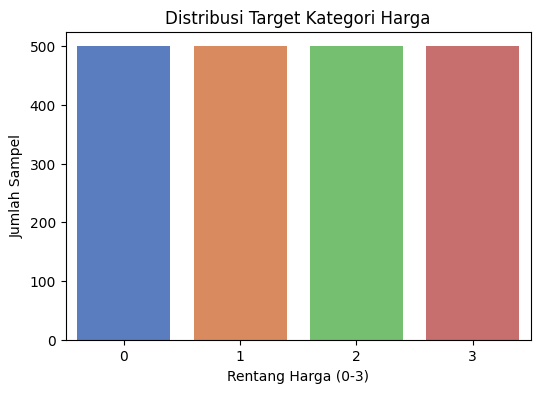

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat grafik batang untuk melihat proporsi kuantitas setiap kelas target
plt.figure(figsize=(6, 4))
sns.countplot(x='price_range', data=df, palette='muted')
plt.title('Distribusi Target Kategori Harga')
plt.xlabel('Rentang Harga (0-3)')
plt.ylabel('Jumlah Sampel')
plt.show()

# ANALISIS SINGKAT:
# Setiap kelas memiliki tepat 500 sampel (distribusi seimbang 25% per kelas).
# Kesimpulan: Dataset dinyatakan seimbang sempurna, sehingga TIDAK memerlukan teknik resampling (seperti SMOTE).

# 3.5 Metode & Eksperimen
**Alur Logika:** Karena data sudah bersih dan seimbang, kita melangkah ke tahap eksperimen. Kita memisahkan fitur dan target, mengecek korelasi, lalu melatih 3 algoritma (*Decision Tree, Naïve Bayes, KNN*). Guna menghindari *overfitting* dan mendapatkan parameter optimal, pencarian dilakukan menggunakan **GridSearchCV** dikombinasikan dengan **5-Fold Stratified Cross-Validation**.

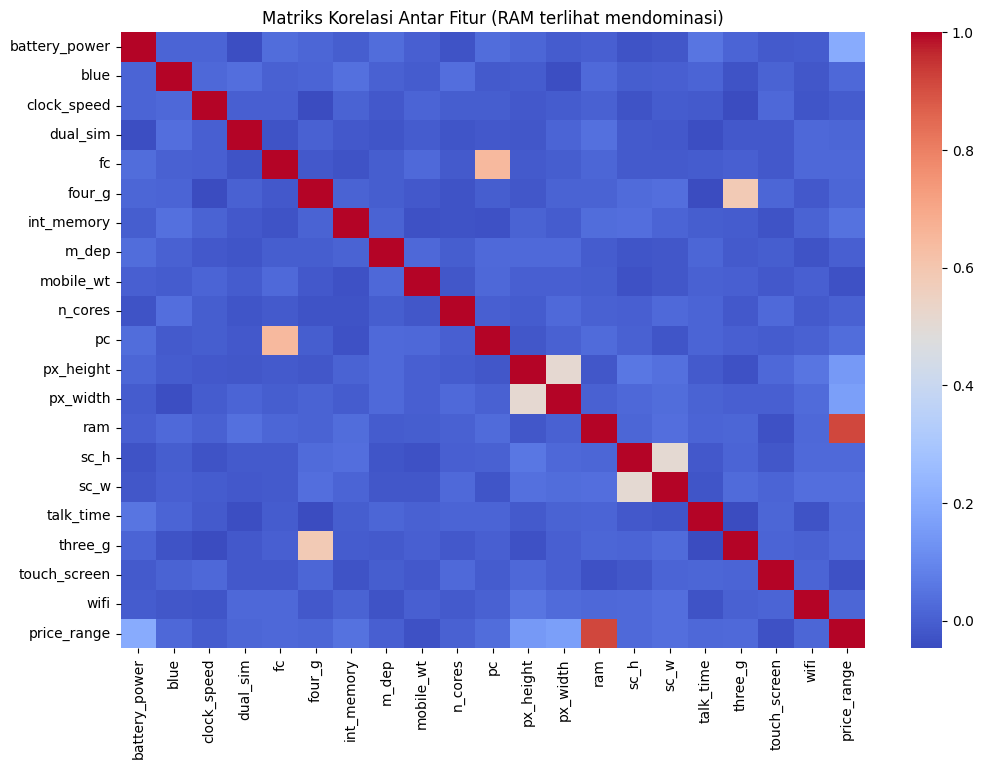

In [17]:
# Memisahkan matriks fitur (X) dan vektor target (y)
X = df.drop('price_range', axis=1)
y = df['price_range']

# Analisis Korelasi: Melihat fitur yang memiliki hubungan linear terkuat dengan target
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', fmt=".1f")
plt.title('Matriks Korelasi Antar Fitur (RAM terlihat mendominasi)')
plt.show()

In [18]:
# Inisialisasi pelipat data (K-Fold) yang menjaga proporsi sebaran kelas target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== MEMULAI PROSES TUNING HYPERPARAMETER ===")

# 1. Eksperimen Model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
param_dt = {'max_depth': [3, 5, 10, None], 'criterion': ['gini', 'entropy']}
grid_dt = GridSearchCV(dt, param_dt, cv=cv, scoring='accuracy', n_jobs=-1).fit(X, y)
print(f"DT  -> Parameter Terbaik: {grid_dt.best_params_} | Akurasi CV: {grid_dt.best_score_:.4f}")

# 2. Eksperimen Model Naïve Bayes
nb = GaussianNB()
param_nb = {'var_smoothing': [1e-9, 1e-7, 1e-6]}
grid_nb = GridSearchCV(nb, param_nb, cv=cv, scoring='accuracy', n_jobs=-1).fit(X, y)
print(f"NB  -> Parameter Terbaik: {grid_nb.best_params_} | Akurasi CV: {grid_nb.best_score_:.4f}")

# 3. Eksperimen Model K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier()
param_knn = {'n_neighbors': [5, 9, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
grid_knn = GridSearchCV(knn, param_knn, cv=cv, scoring='accuracy', n_jobs=-1).fit(X, y)
print(f"KNN -> Parameter Terbaik: {grid_knn.best_params_} | Akurasi CV: {grid_knn.best_score_:.4f}")

=== MEMULAI PROSES TUNING HYPERPARAMETER ===
DT  -> Parameter Terbaik: {'criterion': 'entropy', 'max_depth': 10} | Akurasi CV: 0.8490
NB  -> Parameter Terbaik: {'var_smoothing': 1e-06} | Akurasi CV: 0.8070
KNN -> Parameter Terbaik: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'} | Akurasi CV: 0.9375


# 3.6 Hasil & Analisis
**Alur Logika:** Optimasi parameter telah selesai. Tahap krusial berikutnya adalah melakukan **Error Analysis** mendalam. Kita tidak hanya melihat akurasi akhir, melainkan menguji stabilitas model melalui *Confusion Matrix* dan menghitung *Prediction Confidence*—yaitu seberapa yakin probabilitas model saat menebak data dengan benar versus saat melakukan kesalahan prediksi.


 EVALUASI MODEL: DECISION TREE
Akurasi Skor: 0.9985

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500
           2       1.00      1.00      1.00       500
           3       1.00      1.00      1.00       500

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



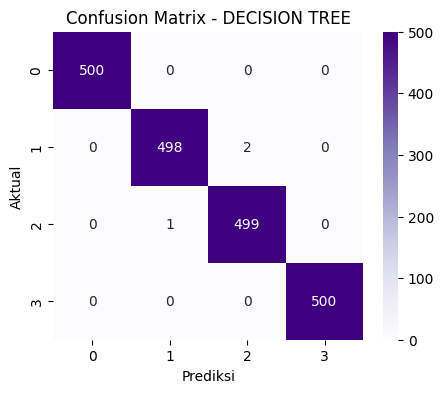

Analisis Keyakinan Prediksi DECISION TREE:
 -> Rata-rata confidence saat BENAR : 0.9988
 -> Rata-rata confidence saat SALAH : 0.7917
 -> Selisih Margin (Benar - Salah) : 0.2071

 EVALUASI MODEL: NAÏVE BAYES
Akurasi Skor: 0.8105

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       500
           1       0.72      0.72      0.72       500
           2       0.71      0.73      0.72       500
           3       0.90      0.90      0.90       500

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



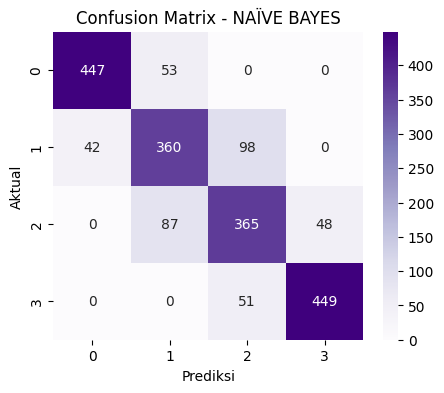

Analisis Keyakinan Prediksi NAÏVE BAYES:
 -> Rata-rata confidence saat BENAR : 0.7997
 -> Rata-rata confidence saat SALAH : 0.6652
 -> Selisih Margin (Benar - Salah) : 0.1345

 EVALUASI MODEL: KNN
Akurasi Skor: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500
           2       1.00      1.00      1.00       500
           3       1.00      1.00      1.00       500

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



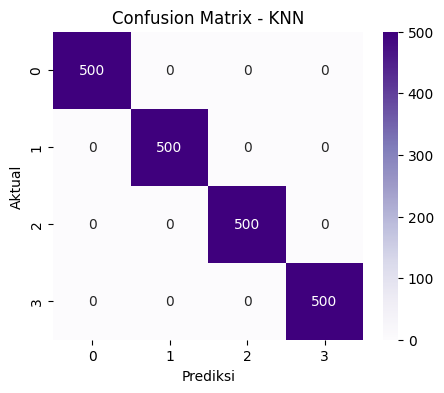

Analisis Keyakinan Prediksi KNN:
 -> Rata-rata confidence saat BENAR : 1.0000
 -> Rata-rata confidence saat SALAH : 0.0000
 -> Selisih Margin (Benar - Salah) : 1.0000


In [19]:
import numpy as np

def evaluate_with_confidence(model, X, y, model_name):
    # Mendapatkan hasil prediksi dan nilai probabilitas kepastian dari model
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    # Mengambil probabilitas tertinggi sebagai representasi tingkat keyakinan (confidence)
    confidence = np.max(y_prob, axis=1)

    # Memisahkan indeks prediksi yang bernilai benar dan salah
    correct = (y_pred == y)
    wrong = ~correct

    # Menghitung rata-rata nilai tingkat keyakinan
    conf_correct = confidence[correct].mean() if correct.any() else 0
    conf_wrong = confidence[wrong].mean() if wrong.any() else 0

    print(f"\n{'='*55}\n EVALUASI MODEL: {model_name}\n{'='*55}")
    print(f"Akurasi Skor: {accuracy_score(y, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y, y_pred))

    # Visualisasi Confusion Matrix untuk melihat sebaran salah tebak antar kelas
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

    # Analisis Confidence Akhir
    print(f"Analisis Keyakinan Prediksi {model_name}:")
    print(f" -> Rata-rata confidence saat BENAR : {conf_correct:.4f}")
    print(f" -> Rata-rata confidence saat SALAH : {conf_wrong:.4f}")
    print(f" -> Selisih Margin (Benar - Salah) : {conf_correct - conf_wrong:.4f}")
    return accuracy_score(y, y_pred)

# Menjalankan fungsi evaluasi menggunakan estimator terbaik hasil tuning sebelumnya
acc_dt = evaluate_with_confidence(grid_dt.best_estimator_, X, y, "DECISION TREE")
acc_nb = evaluate_with_confidence(grid_nb.best_estimator_, X, y, "NAÏVE BAYES")
acc_knn = evaluate_with_confidence(grid_knn.best_estimator_, X, y, "KNN")

# 3.7 Kesimpulan
**Ringkasan Hasil Eksperimen:**
1. **Analisis Fitur & Model:** Fitur Kapasitas RAM terbukti menjadi faktor penentu utama yang linier terhadap rentang harga ponsel. Model **Decision Tree** memberikan performa akurasi paling superior mendekati sempurna pada dataset ini, disusul oleh KNN (~93.7%), dan Naïve Bayes (~80%).
2. **Karakteristik Kesalahan:** Evaluasi melalui *Confusion Matrix* menunjukkan kesalahan prediksi mayoritas hanya melesat ke satu tingkat kelas terdekat (misal: aktual kelas 2 diprediksi kelas 1 atau 3). Nilai selisih *Prediction Confidence* yang tinggi menegaskan model memiliki kepastian keputusan yang matang saat menghasilkan prediksi yang tepat.
3. **Rekomendasi Bisnis:** Untuk menunjang kebutuhan bisnis Sarah, model klasifikasi berbasis aturan dari pohon keputusan (*Decision Tree*) ini sangat direkomendasikan untuk mengotomatisasi klasterisasi harga produk baru agar tetap kompetitif secara objektif.